# Othello-GPT: Probing and Activation Intervention

Can a transformer trained only to predict Othello moves recover the board internally? We use TDHook to read and edit the released Othello-GPT model, following [*Linear Latent World Models in Simple Transformers*](https://arxiv.org/abs/2310.07582).

We will look at three things: the board decoded from an activation, one targeted edit, and the full layer-by-game-length intervention pattern.

## Load the model and games

The model, linear probes, and 100 synthetic games are downloaded on first use and then cached locally.

### Workflow and figure exports

The schematic summarizes the artifact dependencies; the executable `Workflow`
definitions appear below. Model configuration is fixed, while per-example results
pass between stages through TensorDict keys.

Every figure is displayed here and exported to `demo-figures/` in the working
directory as an editable SVG and a 300-dpi PNG. Use the PNG in slides or adapt
the SVG. Experiment sizes, controls, and thresholds are unchanged.

In [1]:
from __future__ import annotations
import importlib.util
import json
import sys
import types
import urllib.request
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import hf_hub_download
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap
from tensordict import NonTensorData, TensorDict
from tensordict.nn import TensorDictModule
from torch.nn import functional as F
from transformer_lens import HookedTransformer, HookedTransformerConfig
from tdhook.interventions import (
    EarlyStoppingConfig,
    InterventionObjective,
    InterventionSpec,
    OptimizerConfig,
    optimize_intervention,
)
from tdhook.latent import ActivationCaching, SteeringVectors
from tdhook.targets import Target

In [2]:
tutorial_path = Path("docs/source/notebooks/tutorials")
tutorial_dir = next(
    (root / tutorial_path for root in (Path.cwd(), *Path.cwd().parents) if (root / tutorial_path).is_dir()), Path.cwd()
)
sys.path.insert(0, str(tutorial_dir))
from demo_figures import STYLE, draw_board, finish_figure, workflow_figure  # noqa: E402

plt.rcParams.update(STYLE)

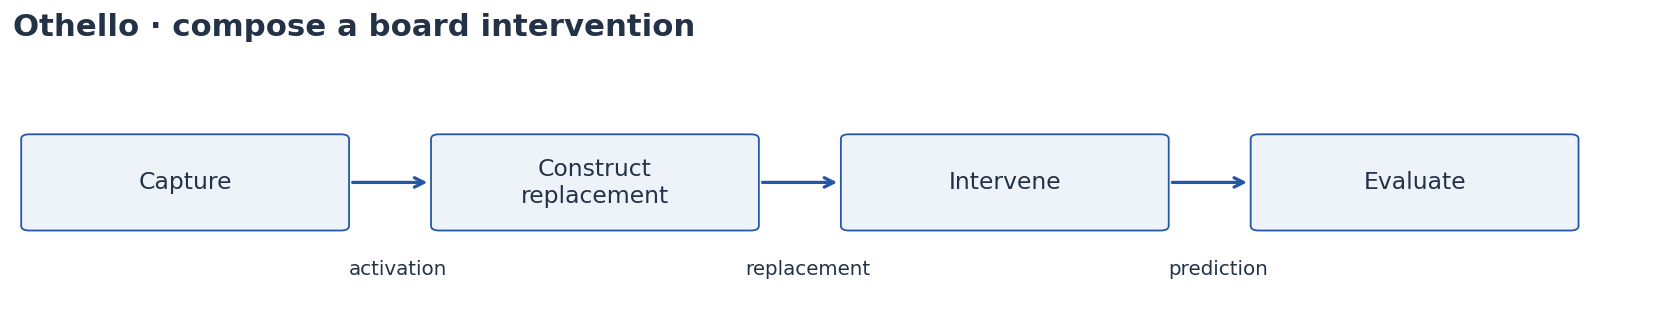

In [3]:
workflow_figure(
    "Othello · compose a board intervention",
    ["Capture", "Construct\nreplacement", "Intervene", "Evaluate"],
    ["activation", "replacement", "prediction"],
    "othello-research-reproduction" + "-workflow",
);

In [4]:
from tdhook.workflow import Workflow

OTHELLO_REVISION = "f23bb5696cf30b93bd8af8a391ee33fc3aac417e"
HF_REVISION = "905ca1a68b9f7dff77adc56af1962e5f6fcac274"
CACHE = Path.home() / ".cache" / "tdhook" / "othello-reproduction"
CACHE.mkdir(parents=True, exist_ok=True)
BASE = f"https://raw.githubusercontent.com/likenneth/othello_world/{OTHELLO_REVISION}"
ASSETS = {
    "main_linear_probe.pth": f"{BASE}/mechanistic_interpretability/main_linear_probe.pth",
    "board_seqs_int_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_int_small.npy",
    "board_seqs_string_small.npy": f"{BASE}/mechanistic_interpretability/board_seqs_string_small.npy",
    "othello.py": f"{BASE}/data/othello.py",
}

In [5]:
def fetch(name):
    path = CACHE / name
    if not path.exists():
        urllib.request.urlretrieve(ASSETS[name], path)
    return path

In [6]:
paths = {name: fetch(name) for name in ASSETS}
model_path = Path(
    hf_hub_download(
        repo_id="NeelNanda/Othello-GPT-Transformer-Lens",
        filename="synthetic_model.pth",
        revision=HF_REVISION,
        token=False,
    )
)

In [7]:
# The released simulator imports pgn only for championship-data utilities.
sys.modules.setdefault("pgn", types.ModuleType("pgn"))
spec = importlib.util.spec_from_file_location("released_othello", paths["othello.py"])
othello = importlib.util.module_from_spec(spec)
spec.loader.exec_module(othello)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = HookedTransformerConfig(
    n_layers=8,
    d_model=512,
    d_head=64,
    n_heads=8,
    d_mlp=2048,
    d_vocab=61,
    n_ctx=59,
    act_fn="gelu",
    normalization_type="LNPre",
    device=str(device),
)
model = HookedTransformer(cfg)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
model.eval()
probe = torch.load(paths["main_linear_probe.pth"], map_location=device, weights_only=False)
games_int = torch.from_numpy(np.load(paths["board_seqs_int_small.npy"])[:100, :59].astype(np.int64)).to(device)
games_string = np.load(paths["board_seqs_string_small.npy"])[:100, :59]
display(Markdown(f"**Ready:** 100 games · 8-layer model · `{device}`"))

**Ready:** 100 games · 8-layer model · `cuda`

## Decode the internal board

A two-step `Workflow` captures the residual stream after layer 7 into a named TensorDict artifact, then applies the released linear probe. The example below compares the real board with the board decoded from a single activation.

Replay the games to build ground-truth board labels before reading model activations.

In [8]:
def board_labels(games_string, othello, device):
    """Replay games and encode empty, black, and white squares."""
    states = []
    for sequence in games_string:
        board = othello.OthelloBoardState()
        sequence_states = []
        for move in sequence.tolist():
            board.umpire(int(move))
            sequence_states.append(board.state.copy())
        states.append(np.stack(sequence_states))
    states = torch.from_numpy(np.stack(states))
    labels = torch.empty(states.shape, dtype=torch.long)
    labels[states == 0], labels[states == -1], labels[states == 1] = 0, 1, 2
    labels = labels.to(device)
    return labels

In [9]:
labels = board_labels(games_string, othello, device)
residual_target = Target("blocks.6.hook_resid_post", "activation", -1, tuple(range(512)))
residual_key = ("activations", "layer_7", residual_target.module_path)
decode_probe = TensorDictModule(
    lambda residual: torch.einsum("bpd,mdrco->mbprco", residual, probe),
    in_keys=[residual_key],
    out_keys=[("representations", "board_logits")],
)

Compose activation capture and probe decoding. The following cell runs the workflow on the released games.

In [10]:
representation_workflow = Workflow(
    ActivationCaching(residual_target, cache_key=("activations", "layer_7")),
    decode_probe,
)

In [11]:
with torch.inference_mode():
    representation = representation_workflow(model, TensorDict({"input": games_int}, batch_size=[]))
captured = representation[residual_key]
logits = representation["output"]
probe_logits = representation[("representations", "board_logits")]
probe_correct = probe_logits.argmax(-1) == labels.unsqueeze(0)
lo, hi = 5, 54
odd_accuracy = float(probe_correct[0, :, lo:hi:2].float().mean().cpu())
even_accuracy = float(probe_correct[1, :, lo + 1 : hi : 2].float().mean().cpu())
designated_accuracy = (odd_accuracy + even_accuracy) / 2

In [12]:
def legal_move_rate(logits, games_string, othello):
    """Measure legal next-move predictions on the released games."""
    playable = [index for index in range(64) if index not in (27, 28, 35, 36)]
    illegal = total = 0
    predicted_tokens = logits.argmax(-1).cpu().numpy()
    for game_index, sequence in enumerate(games_string):
        board = othello.OthelloBoardState()
        for position, move in enumerate(sequence.tolist()):
            board.umpire(int(move))
            if position < 58:
                token = int(predicted_tokens[game_index, position])
                predicted_square = -1 if token == 0 else playable[token - 1]
                illegal += int(predicted_square not in board.get_valid_moves())
                total += 1
    legal_rate = 1 - illegal / total
    return legal_rate, total

In [13]:
legal_rate, total = legal_move_rate(logits, games_string, othello)
game_index, position = 8, 30
probe_mode = 1 if position % 2 == 0 else 0
actual_board = labels[game_index, position].detach().cpu()
decoded_board = probe_logits[probe_mode, game_index, position].argmax(-1).detach().cpu()
cmap = ListedColormap(["#e2e8f0", "#0f172a", "#f97316"])

In [14]:
def plot_decoded_board(actual_board, decoded_board, cmap):
    with plt.rc_context(STYLE):
        figure, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
        draw_board(axes[0], actual_board, "Actual board")
        draw_board(axes[1], decoded_board, "Decoded from layer 7")
        figure.suptitle("A board representation inside Othello-GPT", fontsize=20)
        finish_figure(figure, "othello-board-decoding")

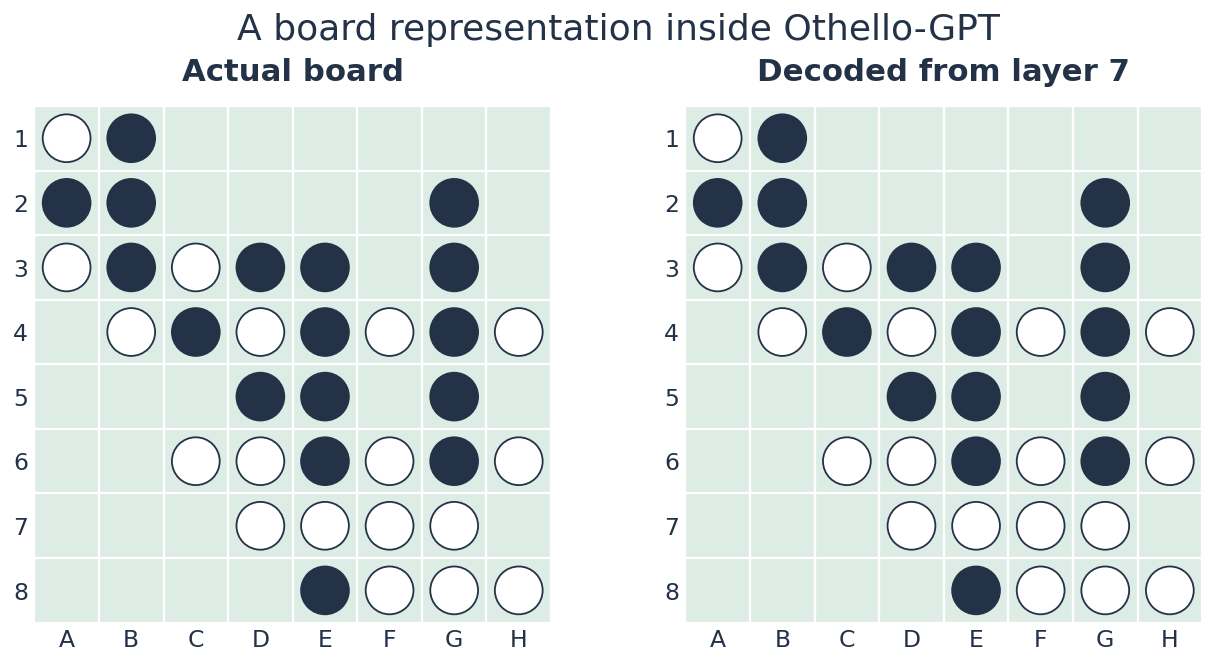

**99.28%** of board squares decoded correctly  ·  **99.93%** legal next moves across 5,800 positions

In [15]:
plot_decoded_board(actual_board, decoded_board, cmap)
display(
    Markdown(
        f"**{designated_accuracy:.2%}** of board squares decoded correctly  ·  "
        f"**{legal_rate:.2%}** legal next moves across {total:,} positions"
    )
)

## Edit one square

The intervention workflow captures the selected activation, constructs a replacement artifact, applies it, and derives the log-probability metric. We compare it with the original TransformerLens hook. A separate optimization workflow produces an optimized intervention artifact and decodes its board with the probe.

In [16]:
game = games_int[8:9, :51]
position, layer, row, column, scale = 50, 3, 7, 4, 4
direction = probe[0, :, row, column, 2] - probe[0, :, row, column, 1]
direction = direction / direction.norm()
position_target = Target(f"blocks.{layer}.hook_resid_post", "activation", -2, (position,))
activation_key = ("activations", "selected", position_target.module_path)
construct_replacement = TensorDictModule(
    lambda activation: activation - (scale + 1) * (activation @ direction).unsqueeze(-1) * direction,
    in_keys=[activation_key],
    out_keys=[("interventions", "replacement")],
)

One workflow now carries the selected activation through replacement construction, intervention, and scoring. The intervention step consumes the replacement key directly.

In [17]:
def apply_replacement(inputs, value):
    method = SteeringVectors([position_target], lambda **_: value)
    with torch.inference_mode(), method.prepare(model) as hooked:
        return hooked(TensorDict({"input": inputs}, batch_size=[]))["output"]

In [18]:
intervention_workflow = Workflow(
    ActivationCaching(position_target, cache_key=("activations", "selected")),
    construct_replacement,
    TensorDictModule(
        apply_replacement, in_keys=["input", ("interventions", "replacement")], out_keys=[("interventions", "logits")]
    ),
    TensorDictModule(
        lambda output: output.log_softmax(-1),
        in_keys=[("interventions", "logits")],
        out_keys=[("metrics", "log_probabilities")],
    ),
)

In [19]:
with torch.inference_mode():
    intervention = intervention_workflow(model, TensorDict({"input": game}, batch_size=[]))
activation = intervention[activation_key]
replacement = intervention["interventions", "replacement"]
tdhook_log_probs = intervention["metrics", "log_probabilities"]

In [20]:
def reference_hook(residual, hook):
    coefficient = residual[0, position] @ direction
    residual[0, position] -= (scale + 1) * coefficient * direction

In [21]:
with torch.inference_mode():
    reference_log_probs = model.run_with_hooks(
        game, fwd_hooks=[(f"blocks.{layer}.hook_resid_post", reference_hook)]
    ).log_softmax(-1)
max_abs_difference = float((tdhook_log_probs - reference_log_probs).abs().max().cpu())
probe_mode = 1 if position % 2 == 0 else 0
target_board = labels[8, position].clone()
target_board[row, column] = 1 if target_board[row, column] != 1 else 2

In [22]:
def probe_board_objective(_model_output, intervention):
    board_logits = torch.einsum("...d,drco->...rco", intervention, probe[probe_mode])
    desired = target_board.expand(*intervention.shape[:-1], 8, 8)
    probe_loss = F.cross_entropy(board_logits.flatten(0, -2), desired.flatten())
    return InterventionObjective(probe_loss, {"probe_cross_entropy": probe_loss})

In [23]:
def optimize_board_intervention(model, game, position_target, probe_board_objective):
    """Optimize the selected activation with the fixed reproduction settings."""
    optimized = optimize_intervention(
        model,
        (game,),
        InterventionSpec(
            position_target,
            probe_board_objective,
            "linear-probe board cross-entropy",
            max_steps=300,
            optimizer=OptimizerConfig("adam", 5e-2),
            early_stopping=EarlyStoppingConfig(objective_threshold=0.05, min_delta=1e-5, patience=30),
            preservation_regularizer=lambda value, reference: 1e-4 * (value - reference).square().mean(),
        ),
        seed=44,
    )
    return optimized

In [24]:
def optimize_board(inputs):
    result = optimize_board_intervention(model, inputs, position_target, probe_board_objective)
    return NonTensorData(result)


def decode_optimized_board(result):
    value = result.interventions[0].value
    with torch.inference_mode():
        return torch.einsum("...d,drco->...rco", value, probe[probe_mode]).argmax(-1)[0, 0].cpu()

In [25]:
optimization_workflow = Workflow(
    TensorDictModule(optimize_board, ["input"], [("interventions", "optimized")]),
    TensorDictModule(decode_optimized_board, [("interventions", "optimized")], [("views", "optimized_board")]),
)
optimization_result = optimization_workflow(model, TensorDict({"input": game}, []))
optimized = optimization_result["interventions", "optimized"]
optimized_board = optimization_result["views", "optimized_board"]
with torch.inference_mode():
    before_board = torch.einsum("...d,drco->...rco", activation, probe[probe_mode]).argmax(-1)[0, 0].cpu()

In [26]:
def plot_board_intervention(before_board, target_board, optimized_board, row, column, cmap):
    with plt.rc_context(STYLE):
        figure, axes = plt.subplots(1, 3, figsize=(13, 4.8), constrained_layout=True)
        for axis, board, title in zip(
            axes,
            (before_board, target_board.cpu(), optimized_board),
            ("Before intervention", "Requested board", "After optimization"),
        ):
            draw_board(axis, board, title, highlight=(row, column))
        figure.suptitle(f"Editing the decoded board · square {'ABCDEFGH'[column]}{row + 1}", fontsize=20)
        finish_figure(figure, "othello-board-intervention")

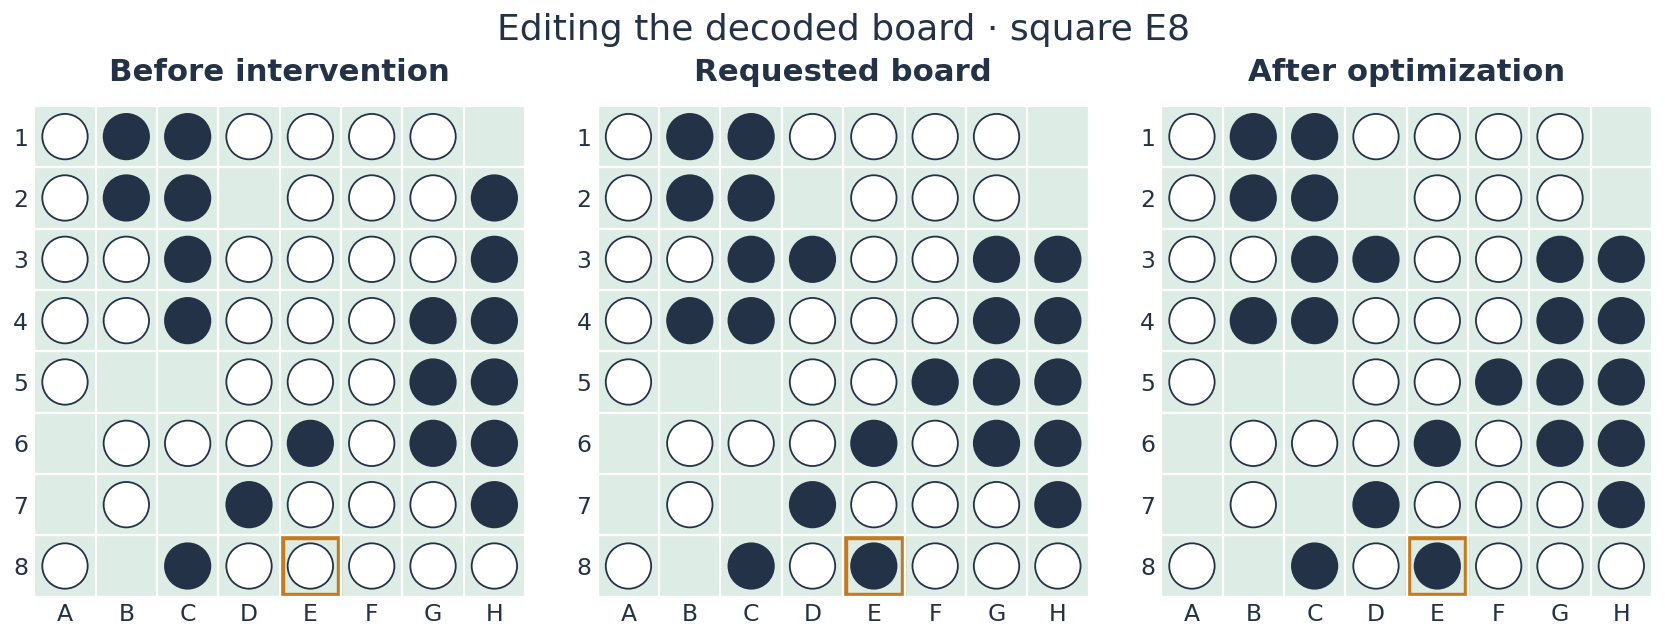

The optimized activation matches the requested board after **4 steps**. TDHook differs from the reference hook by only **0.0e+00** at most.

In [27]:
plot_board_intervention(before_board, target_board, optimized_board, row, column, cmap)
display(
    Markdown(
        f"The optimized activation matches the requested board after "
        f"**{optimized.stages[0].steps_completed} steps**. TDHook differs from the reference hook by "
        f"only **{max_abs_difference:.1e}** at most."
    )
)

## Across the model

Now we repeat the paper's intervention across 50 games, all eight layers, and several game lengths. The controls use the wrong layer, a randomized probe, or a no-op replacement.

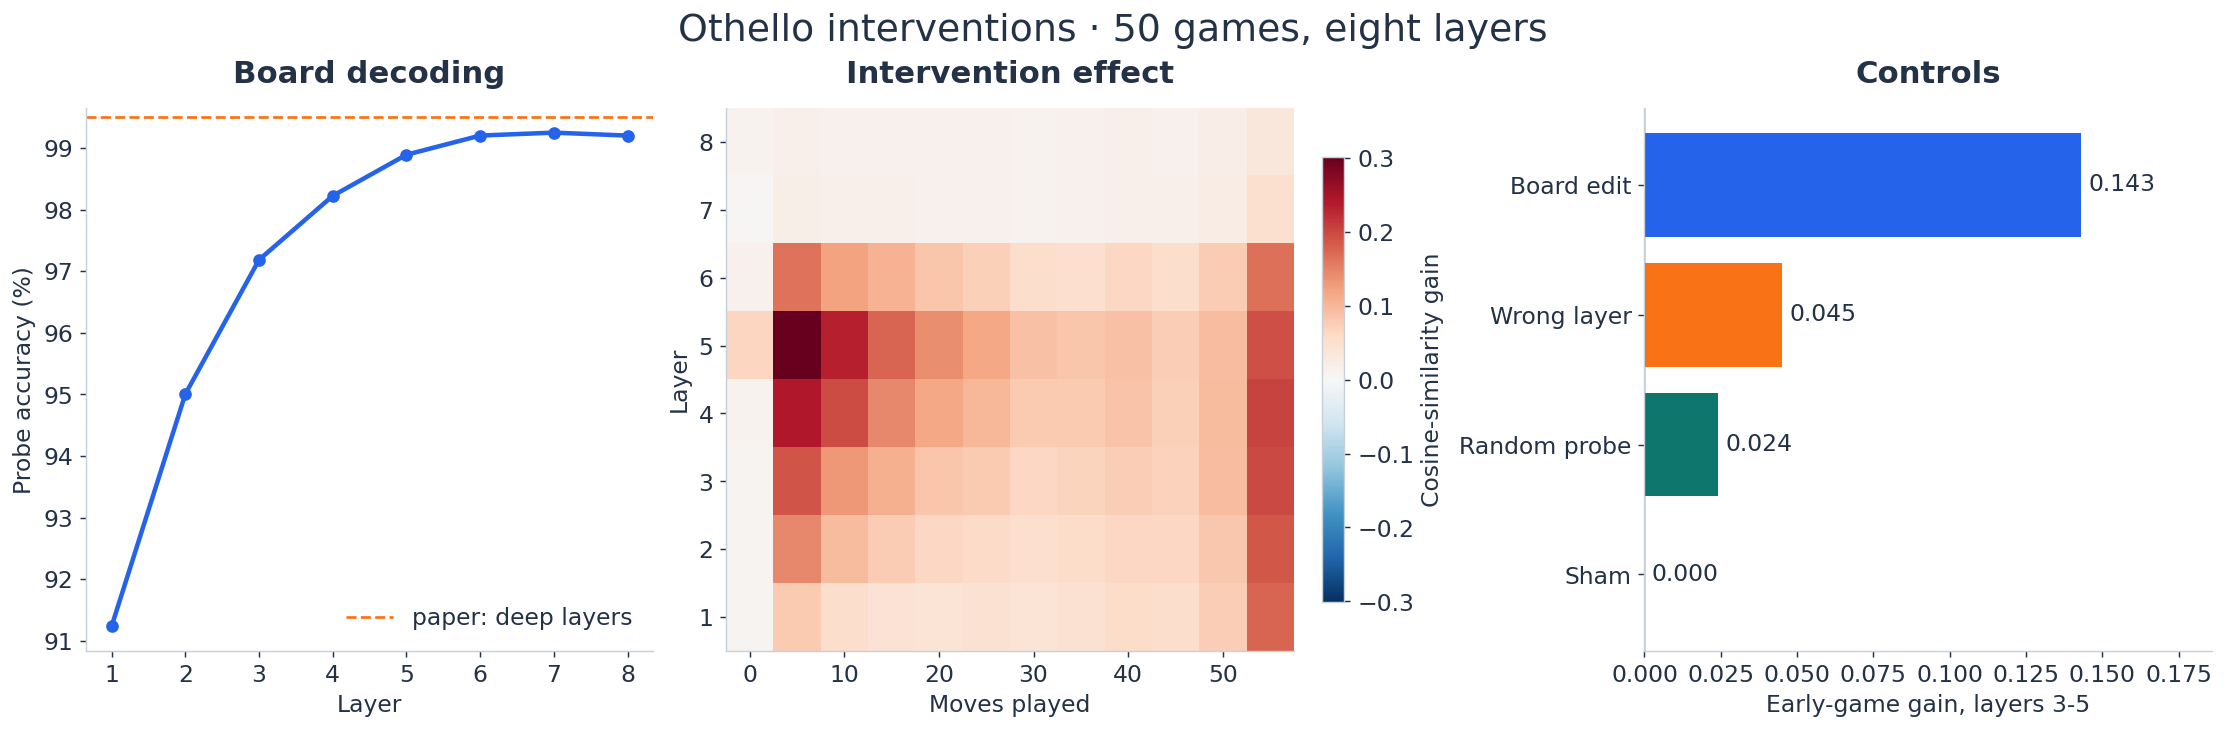

In the early game, editing middle layers has **0.130** more effect than editing late layers (95% bootstrap interval **0.125–0.136**).

In [28]:
from othello_figure4 import plot_figure4_reproduction, run_figure4_reproduction

figure4 = run_figure4_reproduction(
    cache=CACHE,
    games_int=games_int.detach().cpu().numpy(),
    games_string=games_string,
    othello=othello,
    number_games=50,
    seed=44,
)

Path("demo-figures").mkdir(exist_ok=True)
Path("demo-figures/othello-results.json").write_text(json.dumps(figure4, indent=2))
figure = plot_figure4_reproduction(figure4)
finish_figure(figure, "othello-intervention-controls")
ordering = figure4["middle_over_late"]
lower, upper = ordering["interval"]
display(
    Markdown(
        f"In the early game, editing middle layers has **{ordering['mean']:.3f}** more "
        f"effect than editing late layers (95% bootstrap interval **{lower:.3f}–{upper:.3f}**)."
    )
)

## Takeaway

The model's residual stream contains a board representation that becomes sharply readable in later layers. Editing that representation changes move predictions most strongly in the middle of the network, while the sham and randomized controls stay near zero—the same qualitative pattern as Figure 4.

## Reading the slide figures

The decoding baseline uses 100 games; the intervention/control sweep uses 50.
The requested board is the simulator state with the highlighted square flipped.
Optimization can also correct other initial probe-decoding errors: the figure
does not claim that only one decoded square changes. Disc colors follow the
released simulator (+1 black, -1 white). The intervention heatmap uses a symmetric
scale around zero. `demo-figures/othello-results.json` stores the numerical report
and bootstrap intervals for replotting without another model run.
